# Clouds Everywhere â€” Demo
Search free optical satellite imagery by study area and cloud coverage threshold.

In [1]:
import sys, os
# Make the library importable when running the notebook from its own directory
sys.path.insert(0, os.path.abspath('.'))

from search import search_images
from models import SatelliteImage
print('Library loaded.')

Library loaded.


## 1. Define your study area

In [2]:
# Two bounding boxes:
#   bbox        — study area for coverage analysis & heatmap (Madrid region)
#   bbox_country — full Spain for the spatial tile map
bbox         = [-4.5, 39.5, -2.5, 41.0]   # Madrid / central Spain
bbox_country = [-9.3, 35.9,  4.3, 43.8]   # all Spain

start_date = "2024-01-01"
end_date   = "2024-01-31"
max_cloud  = 20

print(f"Study area : {bbox}")
print(f"Country    : {bbox_country}")
print(f"Dates      : {start_date}  ->  {end_date}")
print(f"Max cloud  : {max_cloud}%")

Study area : [-4.5, 39.5, -2.5, 41.0]
Country    : [-9.3, 35.9, 4.3, 43.8]
Dates      : 2024-01-01  ->  2024-01-31
Max cloud  : 20%


## 2. Search all satellites

In [3]:
images = search_images(bbox, start_date, end_date, max_cloud=max_cloud)
print(f'Found {len(images)} images across all satellites')

Found 133 images across all satellites


## 3. Results table

In [4]:
import pandas as pd

df = pd.DataFrame([
    {'Date': img.date, 'Satellite': img.satellite,
     'Cloud %': img.cloud_cover, 'ID': img.id}
    for img in images
])
df

,Date,Satellite,Cloud %,ID
0,2024-01-01,Sentinel-2,41.659433,S2B_30SUJ_20240101_0_L2A
1,2024-01-01,Sentinel-2,17.374913,S2B_30SVJ_20240101_0_L2A
2,2024-01-01,Sentinel-2,26.498482,S2B_30TUK_20240101_0_L2A
3,2024-01-01,Sentinel-2,30.029920,S2B_30TVK_20240101_0_L2A
4,2024-01-01,Sentinel-2,11.452324,S2B_30TUL_20240101_0_L2A
...,...,...,...,...
128,2024-01-31,Sentinel-2,9.156446,S2B_30SVJ_20240131_0_L2A
129,2024-01-31,Sentinel-2,7.210556,S2B_30TUK_20240131_0_L2A
130,2024-01-31,Sentinel-2,53.008974,S2B_30TVK_20240131_0_L2A
131,2024-01-31,Sentinel-2,15.292148,S2B_30TUL_20240131_0_L2A


## 4. Count by satellite

In [5]:
df.groupby('Satellite').size().rename('Count').reset_index()

,Satellite,Count
0,Sentinel-2,97
1,landsat-8,18
2,landsat-9,18


## 5. Query a single satellite

In [6]:
s2 = search_images(bbox, start_date, end_date, max_cloud=max_cloud, satellites=['sentinel2'])
print(f'Sentinel-2: {len(s2)} scenes')
for img in s2[:5]:
    print(img)

Sentinel-2: 97 scenes
2024-01-01 | Sentinel-2 | Cloud: 41.659433%
2024-01-01 | Sentinel-2 | Cloud: 17.374913%
2024-01-01 | Sentinel-2 | Cloud: 26.498482%
2024-01-01 | Sentinel-2 | Cloud: 30.02992%
2024-01-01 | Sentinel-2 | Cloud: 11.452324%


In [7]:
modis_imgs = search_images(bbox, start_date, end_date, max_cloud=max_cloud, satellites=['modis'])
print(f'MODIS: {len(modis_imgs)} scenes')
for img in modis_imgs[:5]:
    print(img)

MODIS: 0 scenes


## 6. Thumbnail previews

In [8]:
from IPython.display import Image, display

with_thumb = [img for img in images if img.thumbnail_url][:3]
for img in with_thumb:
    print(f'{img.date}  |  {img.satellite}  |  Cloud: {img.cloud_cover}%')
    display(Image(url=img.thumbnail_url, width=320))

2024-01-01  |  Sentinel-2  |  Cloud: 41.659433%


2024-01-01  |  Sentinel-2  |  Cloud: 17.374913%


2024-01-01  |  Sentinel-2  |  Cloud: 26.498482%


## 7. Tile Coverage Check
Find out on which dates **all** tiles covering your study area are simultaneously cloud-free.

In [9]:
from coverage import check_coverage

cov = check_coverage(bbox, start_date, end_date, max_cloud=max_cloud)
print(f"{len(cov)} satellite-date combinations analysed")

25 satellite-date combinations analysed


In [10]:
cov_df = pd.DataFrame([
    {
        'Date':           c.date,
        'Satellite':      c.satellite,
        'Status':         c.status,
        'Required Tiles': len(c.required_tiles),
        'Covered':        len(c.covered_tiles),
        'Missing':        ', '.join(c.missing_tiles) if c.missing_tiles else '-',
        'Avg Cloud %':    round(c.avg_cloud, 2) if c.avg_cloud != -1 else 'N/A',
    }
    for c in cov
])
cov_df

,Date,Satellite,Status,Required Tiles,Covered,Missing,Avg Cloud %
0,2024-01-01,Sentinel-2,partial,9,3,"30SUJ, 30TUK, 30TVK, 30SWJ, 30TWK, 30TWL",13.84
1,2024-01-03,Sentinel-2,missing,9,0,"30SUJ, 30SVJ, 30SWJ, 30TUK, 30TUL, 30TVK, 30TV...",N/A
2,2024-01-04,landsat-9,missing,9,0,"P202R031, P202R032, P202R033, P200R031, P200R0...",N/A
3,2024-01-05,landsat-8,missing,9,0,"P201R031, P201R032, P201R033, P200R031, P200R0...",N/A
4,2024-01-06,Sentinel-2,partial,9,5,"30TVL, 30SWJ, 30TWK, 30TWL",8.96
5,2024-01-06,landsat-9,partial,9,1,"P200R031, P200R032, P201R031, P201R032, P201R0...",15.36
6,2024-01-08,Sentinel-2,full,9,9,-,4.56
7,2024-01-11,Sentinel-2,partial,9,3,"30SUJ, 30SVJ, 30TUK, 30SWJ, 30TWK, 30TWL",6.05
8,2024-01-12,landsat-8,missing,9,0,"P202R031, P202R032, P202R033, P200R031, P200R0...",N/A
9,2024-01-13,Sentinel-2,missing,9,0,"30SUJ, 30SVJ, 30SWJ, 30TUK, 30TUL, 30TVK, 30TV...",N/A


In [11]:
full_dates = [c for c in cov if c.status == "full"]
print(f"Fully covered dates: {len(full_dates)}")
for c in full_dates[:10]:
    print(c)

Fully covered dates: 1
2024-01-08 | Sentinel-2 | FULL (9/9 tiles) avg cloud: 4.6%


In [12]:
partial_dates = [c for c in cov if c.status == "partial"]
print(f"Partially covered dates: {len(partial_dates)}")
for c in partial_dates[:5]:
    print(c)
    print(f"  Missing tiles: {c.missing_tiles}")

Partially covered dates: 12
2024-01-01 | Sentinel-2 | PARTIAL (3/9 tiles) avg cloud: 13.8%
  Missing tiles: ['30SUJ', '30TUK', '30TVK', '30SWJ', '30TWK', '30TWL']
2024-01-06 | Sentinel-2 | PARTIAL (5/9 tiles) avg cloud: 9.0%
  Missing tiles: ['30TVL', '30SWJ', '30TWK', '30TWL']
2024-01-06 | landsat-9 | PARTIAL (1/9 tiles) avg cloud: 15.4%
  Missing tiles: ['P200R031', 'P200R032', 'P201R031', 'P201R032', 'P201R033', 'P202R031', 'P202R032', 'P202R033']
2024-01-11 | Sentinel-2 | PARTIAL (3/9 tiles) avg cloud: 6.0%
  Missing tiles: ['30SUJ', '30SVJ', '30TUK', '30SWJ', '30TWK', '30TWL']
2024-01-20 | landsat-9 | PARTIAL (3/9 tiles) avg cloud: 2.5%
  Missing tiles: ['P200R031', 'P200R032', 'P200R033', 'P201R031', 'P201R032', 'P201R033']


## 8. Coverage Heatmap

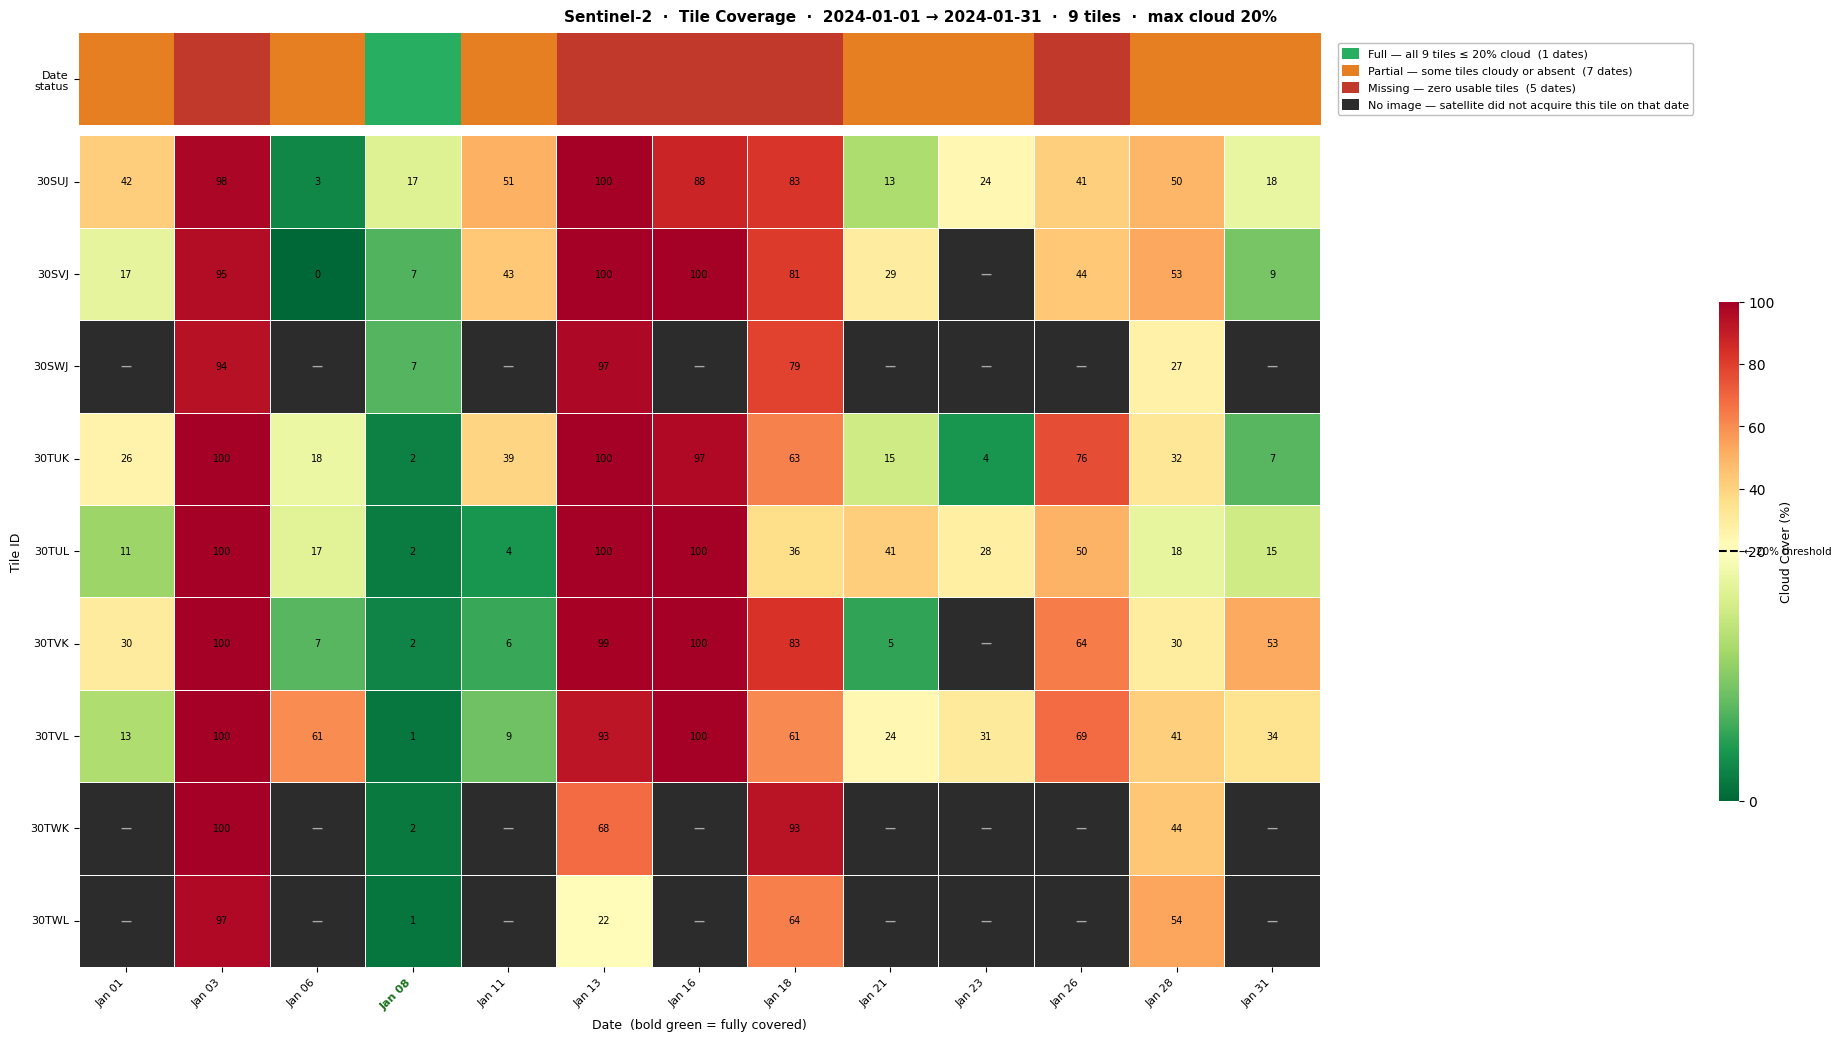

In [13]:
from viz import plot_coverage_heatmap

fig = plot_coverage_heatmap(cov, max_cloud=max_cloud, satellite="Sentinel-2")

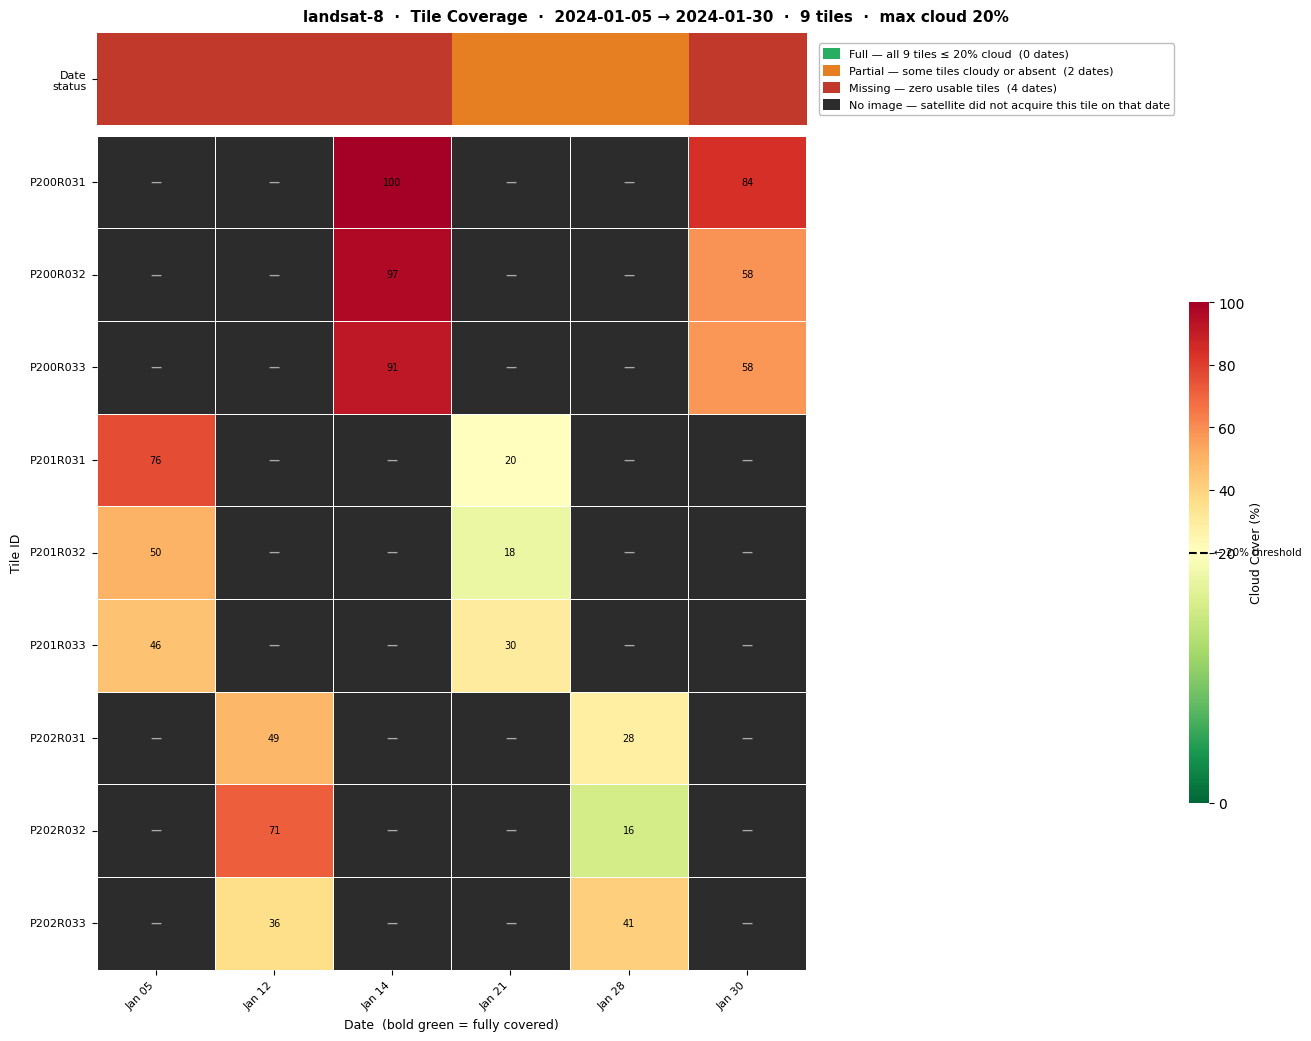

In [14]:
# Landsat coverage heatmap
fig = plot_coverage_heatmap(cov, max_cloud=max_cloud, satellite="landsat-8")

## 9. Spatial Tile Map
Interactive map showing each tile coloured by how often it is cloud-free.

In [15]:
import folium
from collections import defaultdict

# Run a separate coverage query over all Spain just for the spatial map
print("Fetching Spain-wide tile data for spatial map (may take ~30 s)...")
cov_country = check_coverage(bbox_country, start_date, end_date, max_cloud=max_cloud,
                              satellites=["sentinel2"])
print(f"Done — {len(set(t for c in cov_country for t in c.required_tiles))} tiles")

# ── Per-tile summary ────────────────────────────────────────────────────
tile_stats = defaultdict(lambda: {"clouds": [], "geometry": None})
for c in cov_country:
    for tr in c.tile_details:
        ts = tile_stats[tr.tile_id]
        if tr.geometry and ts["geometry"] is None:
            ts["geometry"] = tr.geometry
        if tr.cloud_cover != -1:
            ts["clouds"].append(tr.cloud_cover)

# ── Colour helper ───────────────────────────────────────────────────────
def tile_color(clouds, threshold):
    if not clouds: return "#7f8c8d"
    usable = sum(1 for c in clouds if c <= threshold) / len(clouds)
    if usable >= 0.5: return "#27ae60"
    if usable >= 0.2: return "#e67e22"
    if usable  > 0:   return "#e74c3c"
    return "#7f8c8d"

# ── Build map ───────────────────────────────────────────────────────────
m = folium.Map(location=[40.0, -3.5], zoom_start=6, tiles="CartoDB positron")

# Study area rectangle
folium.Rectangle(
    bounds=[[bbox[1], bbox[0]], [bbox[3], bbox[2]]],
    color="#1a73e8", weight=3, fill=True, fill_opacity=0.10,
    tooltip="Coverage analysis area (Madrid region)"
).add_to(m)

# Country outline rectangle (reference)
folium.Rectangle(
    bounds=[[bbox_country[1], bbox_country[0]], [bbox_country[3], bbox_country[2]]],
    color="#555", weight=1, fill=False, dash_array="6",
    tooltip="Spain bounding box"
).add_to(m)

# Tile polygons
for tile_id, ts in tile_stats.items():
    if not ts["geometry"]: continue
    clouds  = ts["clouds"]
    color   = tile_color(clouds, max_cloud)
    best    = f"{min(clouds):.1f}" if clouds else "N/A"
    usable  = sum(1 for c in clouds if c <= max_cloud)
    total   = len(clouds)
    tooltip = (
        f"<b>Tile {tile_id}</b><br>"
        f"Best cloud cover: {best}%<br>"
        f"Usable / total acquisitions: {usable} / {total}"
    )
    folium.GeoJson(
        ts["geometry"],
        style_function=lambda _, c=color: {
            "fillColor": c, "color": "white",
            "weight": 1.2, "fillOpacity": 0.55
        },
        tooltip=folium.Tooltip(tooltip, sticky=False)
    ).add_to(m)

# HTML legend
legend = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:12px 16px;border-radius:8px;
            border:1px solid #ccc;font-size:12px;line-height:2">
  <b>Tile usability (% of dates below cloud threshold)</b><br>
  <span style="background:#27ae60;padding:2px 14px;border-radius:3px">&nbsp;</span> &ge;50% of dates usable<br>
  <span style="background:#e67e22;padding:2px 14px;border-radius:3px">&nbsp;</span> 20&ndash;50% usable<br>
  <span style="background:#e74c3c;padding:2px 14px;border-radius:3px">&nbsp;</span> &lt;20% usable<br>
  <span style="background:#7f8c8d;padding:2px 14px;border-radius:3px">&nbsp;</span> Never acquired / always cloudy<br>
  <span style="background:#1a73e8;padding:2px 14px;border-radius:3px;opacity:0.4">&nbsp;</span> Coverage analysis area
</div>
"""
m.get_root().html.add_child(folium.Element(legend))
m

Fetching Spain-wide tile data for spatial map (may take ~30 s)...
Done — 146 tiles
